# **Version 10 개선 방향**

- 컴파일 시 Loss 함수를 CategoricalFocalCrossentropy 로 변경

# **데이터 로드 및 증강**

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow-addons

In [ ]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.metrics import structural_similarity as ssim

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 모델 설계
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
Flatten, Dropout, BatchNormalization, Embedding,
LeakyReLU, GlobalAveragePooling2D, concatenate)
from tensorflow.keras.layers import Lambda, Add, Activation, Multiply

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


In [ ]:
from skimage.metrics import structural_similarity as ssim

# 좌표 연속형 10특징 반환 함수
def build_cont_features(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm, eps=1e-6):

    # 웨이퍼 중심 기준 좌표
    dx = xc - wafer_cx
    dy = yc - wafer_cy

    # 반경 정규화(0~1)
    dist_norm = np.sqrt(dx*dx + dy*dy)    # 좌표 간 거리
    r_norm = np.clip(dist_norm / max(wafer_r_norm, eps), 0.0, 1.0)    # 정규화

    # 각도(라디안) 및 sin/cos
    theta = np.arctan2(dy, dx)    # 각도
    sin_th = np.sin(theta)
    cos_th = np.cos(theta)

    # 파생특징
    area_norm   = bw * bh                           # 결함의 상대적 크기
    aspect_log  = np.log((bw + eps) / (bh + eps))   # 결함의 종횡비
    edge_margin = 1.0 - r_norm                      # 결함과 가장자리간 거리

    # 중심좌표를 [-1,1] 범위로 스케일(반지름 기준)
    x_centered = np.clip((dx / max(wafer_r_norm, eps)), -1.5, 1.5)
    y_centered = np.clip((dy / max(wafer_r_norm, eps)), -1.5, 1.5)

    # 연속형 특징 저장
    cont = np.array([
        x_centered, y_centered, bw, bh,
        r_norm, sin_th, cos_th, area_norm,
        aspect_log, edge_margin
    ], dtype=np.float32)

    # 출력
    return cont, r_norm, theta

# 좌표값 검증 함수
def validate_coordinates(xc, yc, bw, bh):
    xc = np.clip(xc, 0.0, 1.0)
    yc = np.clip(yc, 0.0, 1.0)
    bw = np.clip(bw, 1e-6, 1.0) # 너비가 0이 되지 않도록
    bh = np.clip(bh, 1e-6, 1.0) # 높이가 0이 되지 않도록
    return xc, yc, bw, bh

# 증강 이미지 품질 검증 함수
def validate_augmentation(original_img, augmented_img, min_ssim=0.7):

    # 이미지를 흑백으로 변환하여 구조적 유사도만 비교
    orig_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    aug_gray = cv2.cvtColor(augmented_img, cv2.COLOR_RGB2GRAY)

    # 원본 이미지가 uint8 (0~255)이므로, data_range를 255 설정
    score, _ = ssim(orig_gray, aug_gray, full=True, data_range=255)

    # 점수가 기준치 이상이면 유효한 증강으로 판단
    return score >= min_ssim


def load_original_data_with_base(csv_path, image_root, image_size, fallback_bins=(8,16)):

    # CSV 파일 불러오기
    df = pd.read_csv(csv_path)

    # 정보 저장
    info = ['class','cropped_image','x_center_norm','y_center_norm','width_norm','height_norm']

    # 오류 검증
    for c in info:
        if c not in df.columns:
            raise ValueError(f"CSV에 '{c}' 컬럼이 필요합니다.")

    # 웨이퍼 중심 좌표 저장
    has_wafer = all(c in df.columns for c in ['wafer_cx_norm','wafer_cy_norm','wafer_r_norm'])

    # 리스트 생성
    images, cont_list, rad_bins, sec_bins, labels = [], [], [], [], []

    # 좌표 정보 리스트 생성
    base_coords = []  # (xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm)


    N_RAD, N_SEC = fallback_bins

    # 결함 패턴에 대한 정보 수집
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        img_path = os.path.join(image_root, row['class'], row['cropped_image'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"경고: 이미지를 로드할 수 없습니다 - {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        xc = float(row['x_center_norm'])    # 바운딩 박스 중심 x 좌표
        yc = float(row['y_center_norm'])    # 바운딩 박스 중심 y 좌표
        bw = float(row['width_norm'])       # 바운딩 박스 밑변
        bh = float(row['height_norm'])      # 바운딩 박스 높이
        wafer_cx = float(row['wafer_cx_norm']) if has_wafer else 0.5    # 웨이퍼 중심 x 좌표
        wafer_cy = float(row['wafer_cy_norm']) if has_wafer else 0.5    # 웨이퍼 중심 y 좌표
        wafer_rn = float(row['wafer_r_norm'])  if has_wafer else 0.5    # 웨이퍼의 반지름

        # 7개의 좌표를 바탕으로 연속형 특징 추출
        cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)

        # 범주형 특징 추출
        if 'rad_bin' in df.columns and 'sec_bin' in df.columns:
            rad_bin = int(row['rad_bin']); sec_bin = int(row['sec_bin'])
        else:
            rad_bin = int(np.clip(np.floor(r_norm * N_RAD), 0, N_RAD-1))
            two_pi = 2*np.pi
            sec_bin = int(np.floor(((theta % two_pi)/two_pi) * N_SEC))

        # 리스트에 저장
        images.append(img)
        cont_list.append(cont)
        rad_bins.append(rad_bin)
        sec_bins.append(sec_bin)
        labels.append(row['class'])
        base_coords.append([xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn])

    print(f"-> 원본 데이터 로딩 완료: {len(images)}개 샘플")
    return (np.asarray(images, dtype=np.float32),
            np.asarray(cont_list, dtype=np.float32),
            np.asarray(rad_bins, dtype=np.int32),
            np.asarray(sec_bins, dtype=np.int32),
            np.asarray(labels),
            np.asarray(base_coords, dtype=np.float32))

# 연속형 특징 재계산 함수 ( 증강된 이미지에 대한 좌표 재계산)
def _recompute_cont_from_base(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_rn):
    cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)
    two_pi = 2*np.pi
    rad_bin = int(np.clip(np.floor(r_norm * 8), 0, 7))
    sec_bin = int(np.floor(((theta % two_pi)/two_pi) * 16))
    return cont, rad_bin, sec_bin


# 데이터 증강 함수
def augment_and_balance_data(
    images, cont_features, rad_bins, sec_bins, labels, base_coords,
    augment_params: dict,
    random_state=42
):
    labels_series = pd.Series(labels)
    class_counts = labels_series.value_counts()
    target_count = class_counts.max()
    print(f"-> 데이터 증강 목표 개수 (각 클래스별): {target_count}")

    # 최종 데이터를 담을 리스트 (원본 데이터로 초기화)
    X_img, X_cont, X_rbin, X_sbin, y = \
        list(images), list(cont_features), list(rad_bins), list(sec_bins), list(labels)

    for cls, count in class_counts.items():
        if count >= target_count:
            continue

        needed = target_count - count
        original_indices = np.where(labels == cls)[0]
        print(f"클래스 '{cls}': {needed}개 증강 시작")

        augmented_count = 0
        while augmented_count < needed:
            idx = np.random.choice(original_indices)

            # 증강의 기반이 될 원본 데이터 선택
            original_image_for_aug = images[idx].copy()
            xc, yc, bw, bh, wcx, wcy, wrn = base_coords[idx]

            # 증강 작업을 수행할 이미지 변수 (원본 복사본으로 시작)
            augmented_img = original_image_for_aug.copy()

            # --- 좌우 반전 ---
            if np.random.rand() < augment_params.get('p_hflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=1) # ⭐ augmented_img 사용
                xc = 1.0 - xc

            # --- 상하 반전 ---
            if np.random.rand() < augment_params.get('p_vflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=0) # ⭐ augmented_img 사용
                yc = 1.0 - yc

            # --- 회전 ---
            if np.random.rand() < augment_params.get('p_rotate', 0.0):
                limit = augment_params.get('rotate_limit', 15)
                angle = np.random.uniform(-limit, limit)
                h, w = augmented_img.shape[:2] # ⭐ augmented_img 사용
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                augmented_img = cv2.warpAffine(augmented_img, M, (w, h)) # ⭐ augmented_img 사용

                angle_rad = np.radians(angle)
                x_shifted, y_shifted = xc - 0.5, yc - 0.5
                xc_new = x_shifted * np.cos(angle_rad) - y_shifted * np.sin(angle_rad)
                yc_new = x_shifted * np.sin(angle_rad) + y_shifted * np.cos(angle_rad)
                xc, yc = xc_new + 0.5, yc_new + 0.5

            # 증강된 좌표 유효성 검증
            xc, yc, bw, bh = validate_coordinates(xc, yc, bw, bh)

            # --- 밝기/대비 조절 ---
            if np.random.rand() < augment_params.get('p_brightness_contrast', 0.0):
                alpha = 1.0 + np.random.uniform(-0.2, 0.2)
                beta = 10 * np.random.uniform(-1, 1)
                # augmented_img에 적용하고 uint8로 변환
                augmented_img = np.clip(alpha * augmented_img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

            # 증강된 이미지 품질 검증
            if not validate_augmentation(original_image_for_aug, augmented_img):
                continue

            # 변경된 좌표로 모든 파생 특징 재계산
            new_cont, new_rbin, new_sbin = _recompute_cont_from_base(xc, yc, bw, bh, wcx, wcy, wrn)

            # 증강된 데이터를 리스트에 추가
            X_img.append(augmented_img)
            X_cont.append(new_cont)
            X_rbin.append(new_rbin)
            X_sbin.append(new_sbin)
            y.append(cls)

            # 유효한 증강 샘플 카운트 증가
            augmented_count += 1

        print(f"-> 클래스 '{cls}' 증강 완료 (총 {target_count}개)\n")

    # 6. 최종 데이터를 NumPy 배열로 변환하고 섞기
    X_img, X_cont, X_rbin, X_sbin, y = shuffle(
        np.asarray(X_img, dtype=np.uint8),  # 이미지는 uint8로 변환 후 shuffle
        np.asarray(X_cont, dtype=np.float32),
        np.asarray(X_rbin, dtype=np.int32),
        np.asarray(X_sbin, dtype=np.int32),
        np.asarray(y),
        random_state=random_state
    )

    return X_img, X_cont, X_rbin, X_sbin, y


In [ ]:
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/Defect_Pattern_CNN_Dataset"
zip_file_name = "Pattern_Image_Coordinated_Dataset_v5.zip"
unzipped_dataset_path = "Pattern_Image_Coordinated_Dataset_v5"

# Colab 로컬로 데이터셋 이동 및 복사
print("데이터셋을 Colab 로컬 환경으로 복사합니다...")

# 변수를 사용하여 파일 경로를 동적으로 생성
zip_file_path_in_drive = os.path.join(dataset_path, zip_file_name)
!cp "{zip_file_path_in_drive}" /content/
print("압축 해제를 시작합니다...")
!unzip -o -q /content/"{zip_file_name}" -d /content/
print("데이터셋 준비 완료.")

# 로컬 폴더 목록 확인
print("\n/content/ 폴더 내용 확인:")
!ls -l /content/

데이터셋을 Colab 로컬 환경으로 복사합니다...
압축 해제를 시작합니다...
데이터셋 준비 완료.

/content/ 폴더 내용 확인:
total 159424
drwx------  6 root root      4096 Aug  9 09:16 drive
drwxrwxrwx 10 root root      4096 Aug  8 10:43 Pattern_Image_Coordinated_Dataset_v5
-rw-------  1 root root 163229845 Aug  9 09:16 Pattern_Image_Coordinated_Dataset_v5.zip
drwxr-xr-x  1 root root      4096 Aug  7 13:42 sample_data


In [ ]:

# 데이터셋 경로 설정 및 이미지 크기 조절
csv_path = os.path.join(dataset_path, "bbox_info_v5.csv")
image_root = os.path.join("/content/", unzipped_dataset_path)
image_size = (128, 128)

# 데이터 로드
images, cont_features, rad_bins, sec_bins, labels, base_coords = load_original_data_with_base(csv_path, image_root, image_size)

# 적용할 데이터 증강 기법과 확률을 딕셔너리로 정의
augment_parameters = {
  'p_hflip': 0.5,
  'p_vflip': 0.5,
  'p_rotate': 0.3,
  'rotate_limit': 20, # -20 ~ +20도 사이에서 회전
  'p_brightness_contrast': 0.4
}

# 증강 함수 호출
X_aug_img, X_aug_cont, X_aug_rbin, X_aug_sbin, y_aug = augment_and_balance_data(
images, cont_features, rad_bins, sec_bins, labels, base_coords, augment_params=augment_parameters)

X_train_final = {
    'image': X_aug_img,
    'continuous': X_aug_cont,
    'radial_bin': X_aug_rbin,
    'sector_bin': X_aug_sbin
}
y_train_final = y_aug

100%|██████████| 6255/6255 [00:14<00:00, 418.28it/s] 


-> 원본 데이터 로딩 완료: 6255개 샘플
-> 데이터 증강 목표 개수 (각 클래스별): 1004
클래스 'Edge-Ring': 25개 증강 시작
-> 클래스 'Edge-Ring' 증강 완료 (총 1004개)

클래스 'Loc': 56개 증강 시작
-> 클래스 'Loc' 증강 완료 (총 1004개)

클래스 'Center': 71개 증강 시작
-> 클래스 'Center' 증강 완료 (총 1004개)

클래스 'Random': 150개 증강 시작
-> 클래스 'Random' 증강 완료 (총 1004개)

클래스 'Edge-Loc': 151개 증강 시작
-> 클래스 'Edge-Loc' 증강 완료 (총 1004개)

클래스 'Donut': 470개 증강 시작
-> 클래스 'Donut' 증강 완료 (총 1004개)

클래스 'Near-full': 854개 증강 시작
-> 클래스 'Near-full' 증강 완료 (총 1004개)



In [ ]:
# --- 사전 준비: 라벨 데이터를 모델 학습에 맞게 변환 ---
# 1. 문자 라벨 -> 정수 라벨로 변환 (stratify에 사용)
encoder = LabelEncoder()
y_integer_labels = encoder.fit_transform(y_train_final)

# 2. 정수 라벨 -> 원-핫 인코딩 (모델의 최종 출력과 비교할 때 사용)
# 예: 3개의 클래스가 있다면 [0, 1, 2] -> [[1,0,0], [0,1,0], [0,0,1]]
y_categorical_labels = to_categorical(y_integer_labels)


# --- 데이터 분리 (Train/Test Split) ---
# 1. 분리할 모든 입력 데이터와 라벨을 함수에 전달합니다.
X_img_train, X_img_test, \
X_cont_train, X_cont_test, \
X_rbin_train, X_rbin_test, \
X_sbin_train, X_sbin_test, \
y_train, y_test = train_test_split(
    X_train_final['image'],
    X_train_final['continuous'],
    X_train_final['radial_bin'],
    X_train_final['sector_bin'],
    y_categorical_labels,  # 분리할 라벨 데이터 (원-핫 인코딩된 형태)
    test_size=0.2,
    random_state=42,
    stratify=y_integer_labels  # ★분포 유지를 위해서는 정수 라벨을 사용
)

# 2. 분리된 데이터를 다시 딕셔너리로 묶어주면 관리가 편합니다.
X_train = {
    'image': X_img_train,
    'continuous': X_cont_train,
    'radial_bin': X_rbin_train,
    'sector_bin': X_sbin_train
}

X_test = {
    'image': X_img_test,
    'continuous': X_cont_test,
    'radial_bin': X_rbin_test,
    'sector_bin': X_sbin_test
}


# --- 분리 결과 확인 ---
print("✅ 데이터 분리 완료!")
print(f"훈련 데이터 개수: {len(X_train['image'])}")
print(f"테스트 데이터 개수: {len(X_test['image'])}")

# 클래스 분포 확인
print("\n훈련 데이터셋의 클래스 분포:")
y_train_int_labels = np.argmax(y_train, axis=1)
print(pd.Series(encoder.inverse_transform(y_train_int_labels)).value_counts())

print("\n테스트 데이터셋의 클래스 분포:")
y_test_int_labels = np.argmax(y_test, axis=1)
print(pd.Series(encoder.inverse_transform(y_test_int_labels)).value_counts())

✅ 데이터 분리 완료!
훈련 데이터 개수: 6425
테스트 데이터 개수: 1607

훈련 데이터셋의 클래스 분포:
Donut        804
Edge-Loc     803
Near-full    803
Loc          803
Center       803
Scratch      803
Edge-Ring    803
Random       803
Name: count, dtype: int64

테스트 데이터셋의 클래스 분포:
Edge-Ring    201
Edge-Loc     201
Near-full    201
Center       201
Loc          201
Scratch      201
Random       201
Donut        200
Name: count, dtype: int64


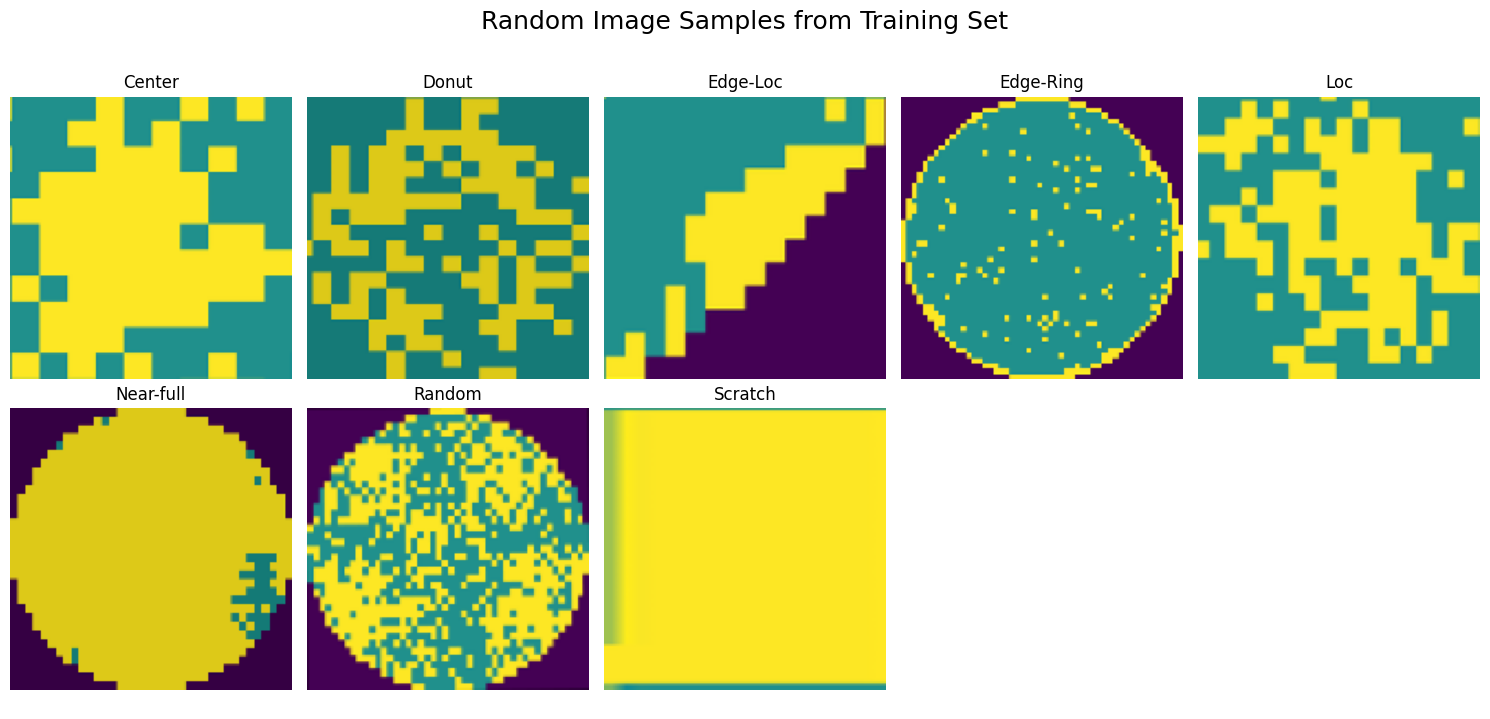

In [ ]:
# 1. 클래스 정보 가져오기
unique_classes = encoder.classes_
num_classes = len(unique_classes)

# 2. 이미지를 출력할 격자(Grid) 설정
cols = 5
# 클래스 개수에 맞춰 행(row) 수를 자동으로 계산합니다.
rows = math.ceil(num_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten() # 2D 배열을 1D로 만들어 쉽게 다룰 수 있게 함

# 3. 각 클래스별로 랜덤 이미지 출력
for i, class_name in enumerate(unique_classes):
    # 현재 클래스에 해당하는 정수 라벨 찾기
    class_code = encoder.transform([class_name])[0]

    # 훈련 세트에서 현재 클래스에 해당하는 모든 이미지의 인덱스를 찾습니다.
    indices_for_class = np.where(y_train_int_labels == class_code)[0]
    # 그 인덱스들 중에서 하나를 무작위로 선택합니다.
    random_index = np.random.choice(indices_for_class)

    # 선택된 랜덤 인덱스로 이미지를 가져옵니다.
    sample_image = X_train['image'][random_index]

    # 격자의 해당 위치(ax)에 이미지와 제목을 표시
    ax = axes[i]
    # .astype('uint8')을 추가하여 이미지를 올바른 형식으로 표시
    ax.imshow(sample_image.astype('uint8'))
    ax.set_title(class_name, fontsize=12)
    ax.axis('off') # 축 번호 숨기기

# 4. 사용되지 않은 빈 격자 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Random Image Samples from Training Set', fontsize=18, y=1.02)
plt.tight_layout() # 이미지들이 겹치지 않게 자동 조절
plt.show()

# **모델 학습**

In [ ]:
# 모델 학습 결과 시각화 함수
def plot_training_history(history, model_name):

  # 정확도 그래프
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.legend()
  plt.grid(True)

  # 손실 그래프
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred_probs, class_names, normalize=False, title='Confusion Matrix'):

  # 확률을 최종 클래스 예측(인덱스)으로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)
  y_true_classes = np.argmax(y_true, axis=1)

  # normalize 옵션 설정
  if normalize:
    # 'true': 실제 라벨(행)을 기준으로 정규화
    cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
    fmt = '.2f' # 소수점 둘째 자리까지 표시
  else:
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    fmt = 'd' # 정수로 표시

  # 혼동 행렬 시각화
  plt.figure(figsize=(9, 8))
  sns.heatmap(
    cm,
    annot=True,
    fmt=fmt, # [개선 2] 포맷 변경
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
  )

  plt.xlabel('Predicted Class', fontsize=12)
  plt.ylabel('Actual Class', fontsize=12)
  plt.title(title, fontsize=15)
  plt.show()


## **1. Multi-Input NN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의

image_input = Input(shape=(128, 128, 3), name='image')    # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')  # 좌표 정보 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')    # 반경 정보 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')    # 섹터 정보 입력

# 이미지 처리 브랜치 (Flatten -> Dense)
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)

# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])

# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])

# 최종 분류층
x1 = Dense(128, activation='relu')(combined)
x1 = Dropout(0.5)(x1) # 과적합 방지를 위한 드롭아웃
x1 = Dense(64, activation='relu')(x1)
output = Dense(num_classes, activation='softmax', name='output')(x1) # num_classes는 이전에 계산됨


# --- 최종 모델 생성 ---
model_simple_nn = Model(
inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
outputs=output
)

# 모델 구조 확인
model_simple_nn.summary()

# --- 모델 컴파일 ---
model_simple_nn.compile(
optimizer='adam',
loss=CategoricalFocalCrossentropy(), # Focal Loss로 변경
metrics=['accuracy']
)
# --- 모델 훈련 ---
history_simple_nn = model_simple_nn.fit(
  X_train, y_train,
  epochs=50,
  batch_size=32,
  validation_data=(X_test, y_test),
  callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 10)        │          0 │ continuous[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │        704 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │        352 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 1)         │          0 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 1)         │          0 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 1)         │          0 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_22 (Lambda)  │ (None, 1)         │          0 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rad_embedding       │ (None, 1, 5)      │         40 │ radial_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sec_embedding       │ (None, 1, 9)      │        144 │ sector_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_24 (Lambda)  │ (None, 1)         │          0 │ sector_bin[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_23[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_25[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │        352 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 1)         │          0 │ lambda_19[0][0],  │
│ (Multiply)          │                   │            │ lambda_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 1)         │          0 │ lambda_21[0][0],  │
│ (Multiply)          │                   │            │ lambda_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 5)         │          0 │ rad_embedding[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 9)         │          0 │ sec_embedding[0]

 Total params: 6,335,080 (24.17 MB)

 Trainable params: 6,334,848 (24.17 MB)

 Non-trainable params: 232 (928.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.1221 - loss: 3.5358 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1204 - loss: 3.5442 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1277 - loss: 3.5151 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1268 - loss: 3.5185 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1204 - loss: 3.5444 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1280 - loss: 3.5138 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1241 - loss: 3.5296 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1277 - loss: 3.5150 - val_accuracy: 

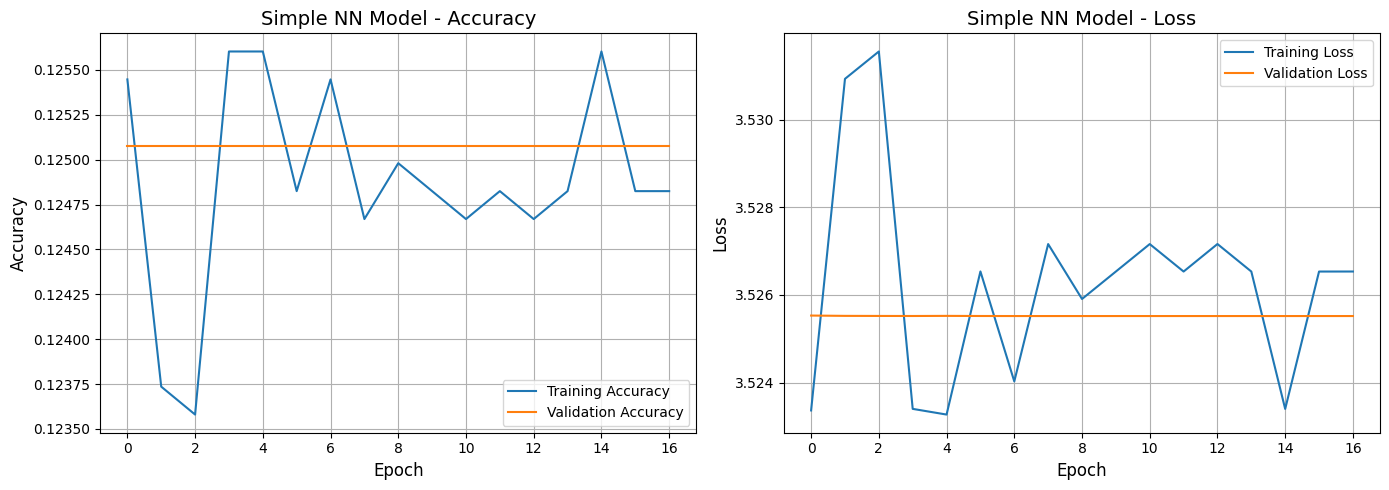

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


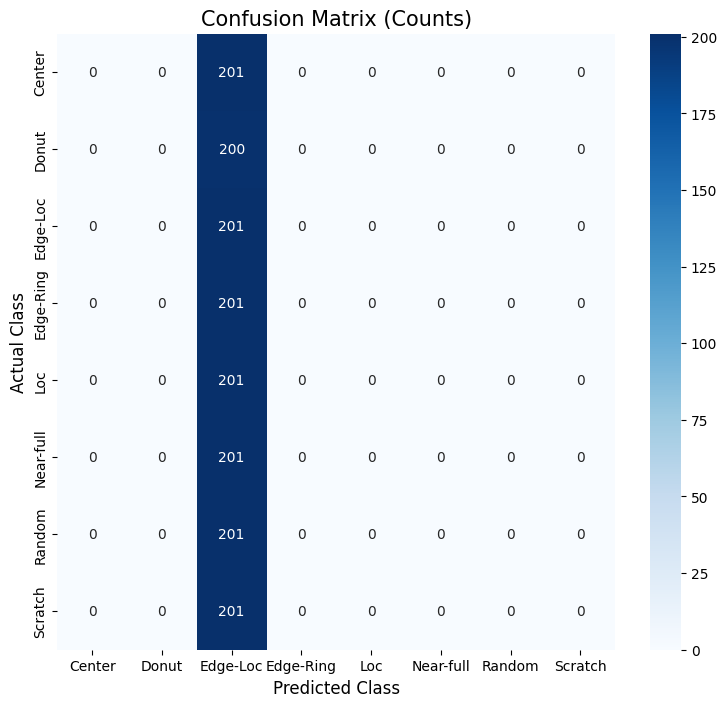

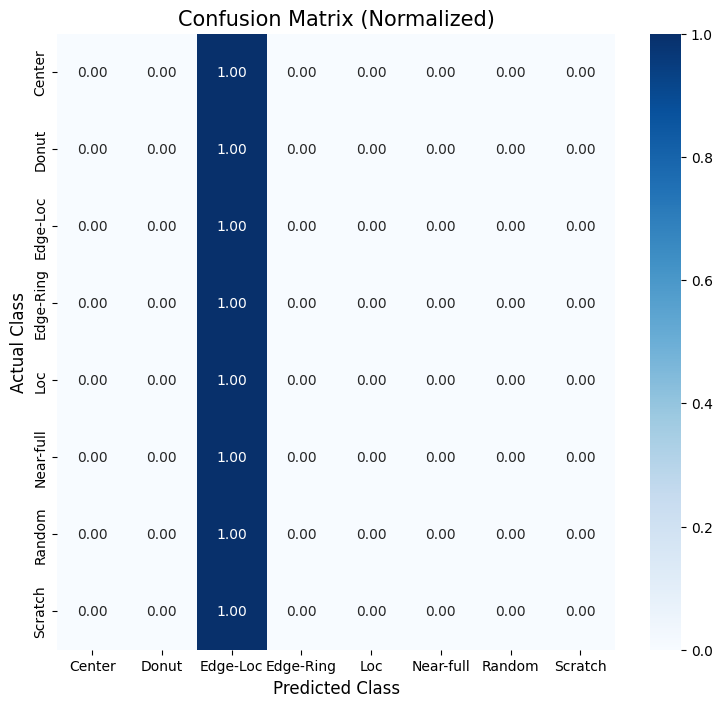

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_simple_nn, "Simple NN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_simple_nn.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **2. Multi-Input DNN**

In [ ]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')

# 이미지 처리 브랜치 (DNN)
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)
image_features = Dense(64, activation='relu')(image_features) # 레이어 추가

# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])

# 브랜치 결합
combined = concatenate([
  image_features,
  continuous_features,
  categorical_features
])

# 최종 분류층
x2 = Dense(128, activation='relu')(combined)
x2 = Dropout(0.5)(x2)
x2 = Dense(64, activation='relu')(x2)
output = Dense(num_classes, activation='softmax', name='output')(x2)

# --- 최종 모델 생성 ---
model_dnn = Model(
  inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
  outputs=output
)

# 모델 구조 확인
model_dnn.summary()

# --- 모델 컴파일 ---
model_dnn.compile(
  optimizer='adam',
  loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
  metrics=['accuracy']
)

# --- 모델 훈련 ---
history_dnn = model_dnn.fit(
  X_train, y_train,
  epochs=50,
  batch_size=32,
  validation_data=(X_test, y_test),
  callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_27 (Lambda)  │ (None, 10)        │          0 │ continuous[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 64)        │        704 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 32)        │        352 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_28 (Lambda)  │ (None, 1)         │          0 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_29 (Lambda)  │ (None, 1)         │          0 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_30 (Lambda)  │ (None, 1)         │          0 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_31 (Lambda)  │ (None, 1)         │          0 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rad_embedding       │ (None, 1, 5)      │         40 │ radial_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sec_embedding       │ (None, 1, 9)      │        144 │ sector_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_33 (Lambda)  │ (None, 1)         │          0 │ sector_bin[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_35[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_37[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 32)        │        352 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 1)         │          0 │ lambda_28[0][0],  │
│ (Multiply)          │                   │            │ lambda_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 1)         │          0 │ lambda_30[0][0],  │
│ (Multiply)          │                   │            │ lambda_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 5)         │          0 │ rad_embedding[0]

 Total params: 6,335,144 (24.17 MB)

 Trainable params: 6,334,912 (24.17 MB)

 Non-trainable params: 232 (928.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.1323 - loss: 3.4955 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1228 - loss: 3.5345 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1222 - loss: 3.5373 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1191 - loss: 3.5496 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1157 - loss: 3.5633 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1281 - loss: 3.5134 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1226 - loss: 3.5354 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1262 - loss: 3.5211 - val_accuracy: 

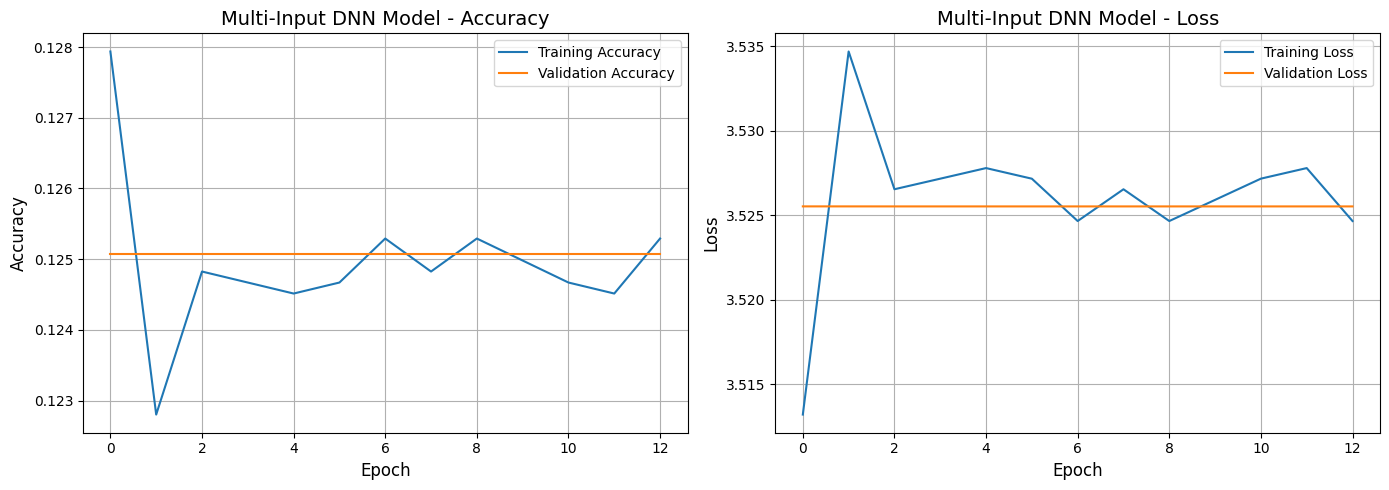

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


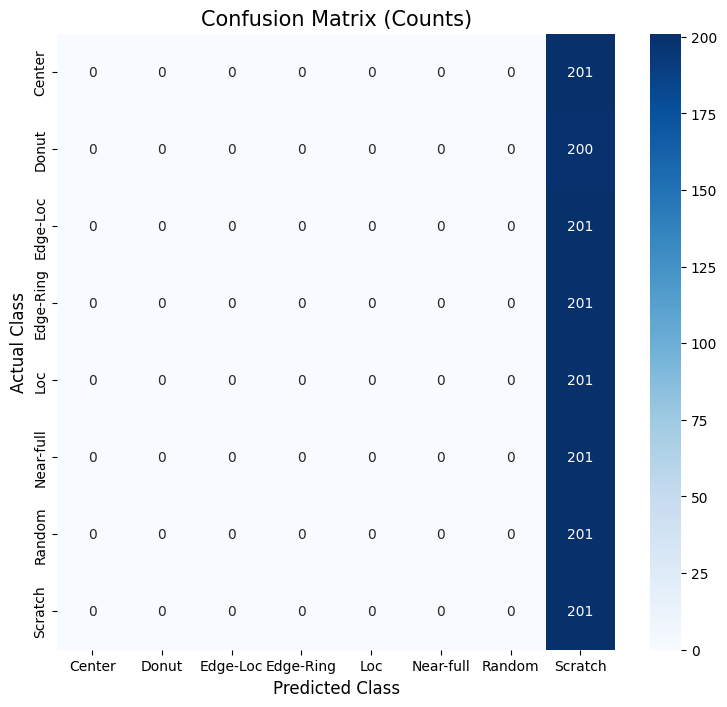

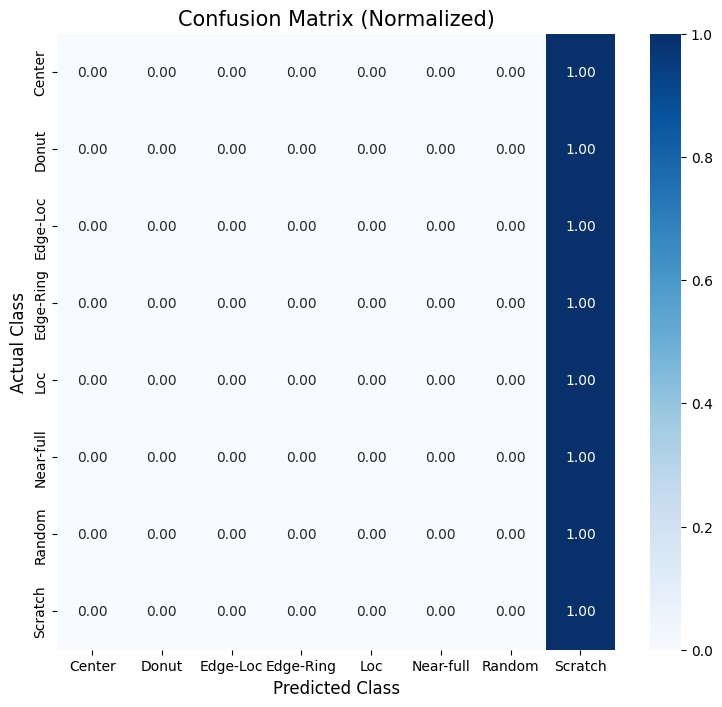

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_dnn, "Multi-Input DNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_dnn.predict(X_test)

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **3. Multi-Input ANN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')



# 이미지 처리 브랜치
x_img = Flatten()(image_input)
x_img = Dense(256)(x_img)
x_img = LeakyReLU(alpha=0.2)(x_img)
x_img = Dropout(0.5)(x_img)
x_img = Dense(128)(x_img)
image_features = LeakyReLU(alpha=0.2)(x_img)

# 10차원 연속형 특징 처리 브랜치
x_cont = Dense(32)(continuous_input)
x_cont = LeakyReLU(alpha=0.2)(x_cont)
x_cont = Dropout(0.3)(x_cont)
continuous_features = Dense(16)(x_cont)
continuous_features = LeakyReLU(alpha=0.2)(continuous_features)

# 반경/섹터 구간 ID 처리 브랜치 (임베딩 레이어)
rad_bin_embedding = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=8)(sec_bin_input)

rad_bin_features = Flatten()(rad_bin_embedding)
sec_bin_features = Flatten()(sec_bin_embedding)


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    rad_bin_features,
    sec_bin_features
])


# 최종 분류층
x = Dense(128)(combined)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)
x = Dense(64)(x)
x = LeakyReLU(alpha=0.2)(x)
# num_classes는 이전에 계산된 클래스의 총 개수입니다.
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_ann = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# 모델 구조 확인
model_ann.summary()


# --- 모델 컴파일 ---
model_ann.compile(
    optimizer='adam',
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)


# --- 모델 훈련 ---
history_ann = model_ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 49152)     │          0 │ image[0][0]       │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 256)       │ 12,583,168 │ flatten_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 32)        │        352 │ continuous[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense_45[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32)        │          0 │ dense_47[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │     32,896 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 16)        │        528 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 4)      │         32 │ radial_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 8)      │        128 │ sector_bin[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16)        │          0 │ dense_48[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 4)         │          0 │ embedding_8[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_22          │ (None, 8)         │          0 │ embedding_9[0][0

 Total params: 12,645,976 (48.24 MB)

 Trainable params: 12,645,976 (48.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.1225 - loss: 3.5351 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1262 - loss: 3.5211 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1186 - loss: 3.5514 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1163 - loss: 3.5606 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1293 - loss: 3.5084 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1227 - loss: 3.5352 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1337 - loss: 3.4909 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1261 - loss: 3.5216 - val_ac

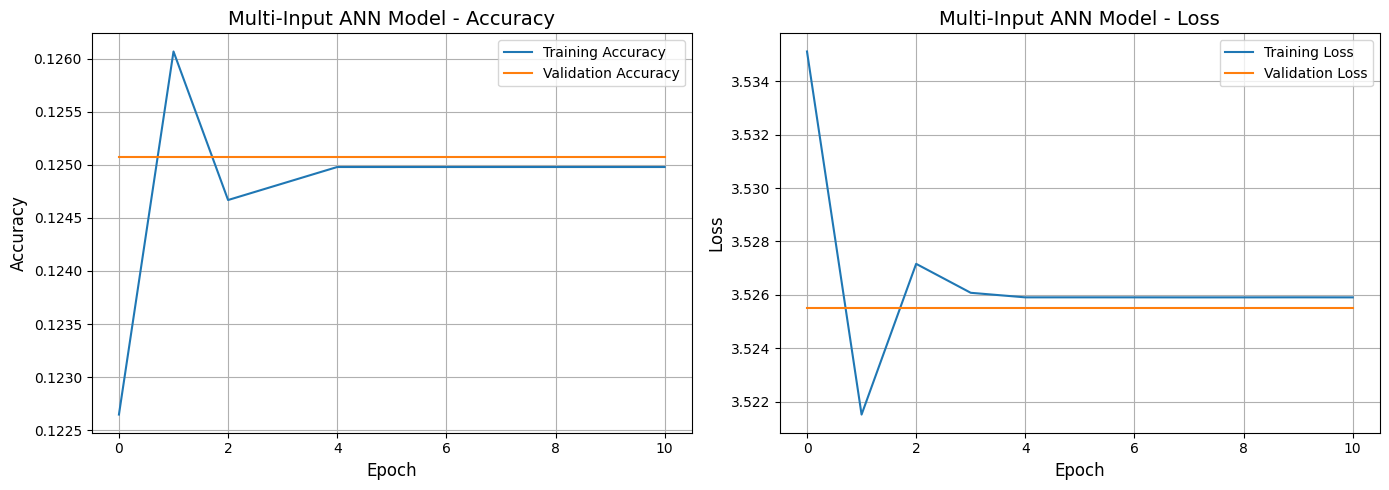

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


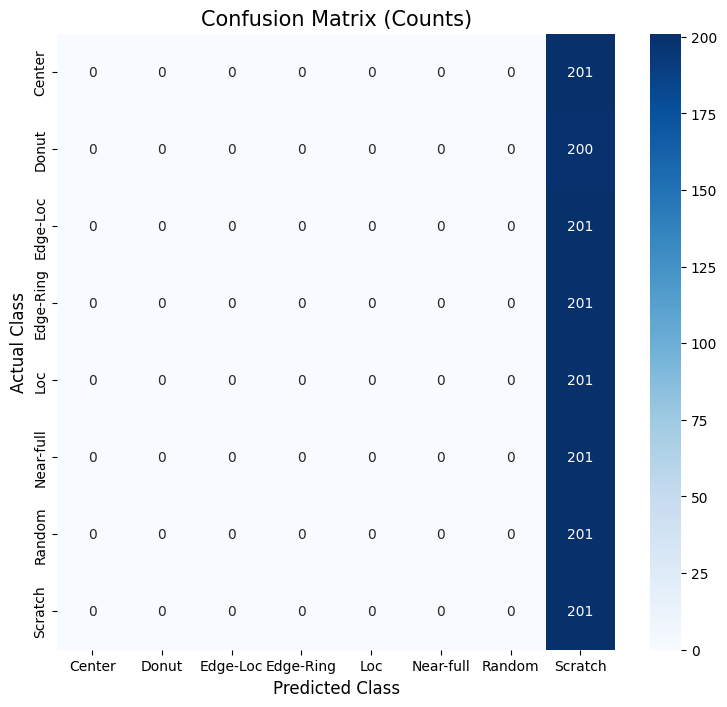

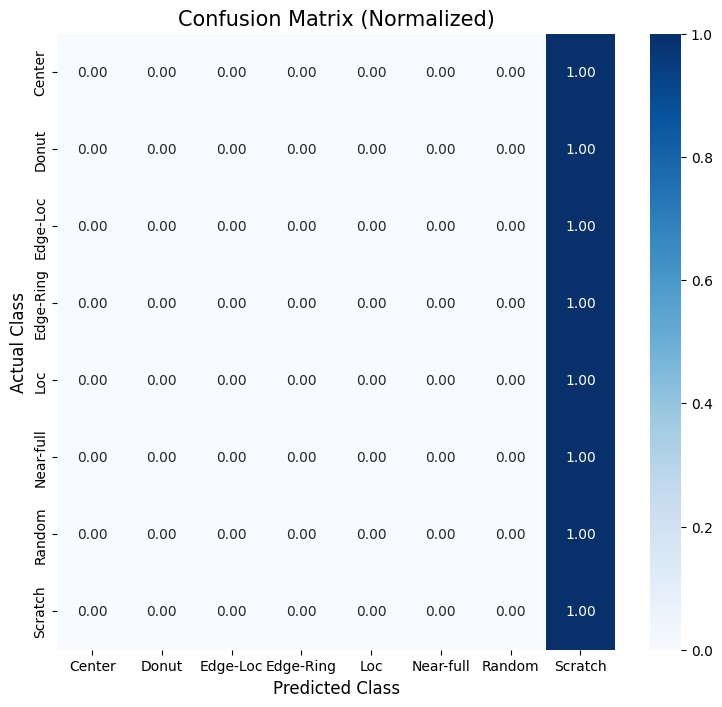

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_ann, "Multi-Input ANN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_ann.predict(X_test)

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **4. Multi-Input CNN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치
x_img = Conv2D(32, (3, 3), activation='relu', padding='same')(image_input)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.3)(x_img)

x_img = Conv2D(64, (3, 3), activation='relu', padding='same')(x_img)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.3)(x_img)

x_img = Conv2D(128, (3, 3), activation='relu', padding='same')(x_img)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.5)(x_img)

image_features = Flatten()(x_img)



# 10차원 연속형 특징 처리 브랜치
continuous_features = Dense(32, activation='relu')(continuous_input)


# 반경/섹터 구간 ID 처리 브랜치 (임베딩 레이어)
rad_bin_embedding = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=8)(sec_bin_input)

rad_bin_features = Flatten()(rad_bin_embedding)
sec_bin_features = Flatten()(sec_bin_embedding)


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    rad_bin_features,
    sec_bin_features
])


# 최종 분류층
x = Dense(128)(combined)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)
x = Dense(64)(x)
x = LeakyReLU(alpha=0.2)(x)
# num_classes는 이전에 계산된 클래스의 총 개수입니다.
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_ann = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)


# 브랜치 통합
combined = concatenate([
    image_features,
    continuous_features,
    rad_bin_features,
    sec_bin_features
])


# 최종 출력층
x = Dense(128, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 모델 구성
model_cnn = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_cnn.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 통합
model_cnn.summary()


# --- 모델 훈련 ---
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout_11[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_12[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 4)      │         32 │ radial_bin[0][0]

 Total params: 4,296,264 (16.39 MB)

 Trainable params: 4,295,560 (16.39 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5767 - loss: 0.2531 - val_accuracy: 0.7057 - val_loss: 0.1306
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7693 - loss: 0.1016 - val_accuracy: 0.6708 - val_loss: 0.1842
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7954 - loss: 0.0891 - val_accuracy: 0.7231 - val_loss: 0.2297
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8147 - loss: 0.0720 - val_accuracy: 0.6907 - val_loss: 0.3312
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8306 - loss: 0.0613 - val_accuracy: 0.6739 - val_loss: 0.3803
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8328 - loss: 0.0636 - val_accuracy: 0.6279 - val_loss: 0.4844
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8558 - loss: 0.0553 - val_accuracy: 0.6864 - val_loss: 0.3958
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8568 - loss: 0.0508 -

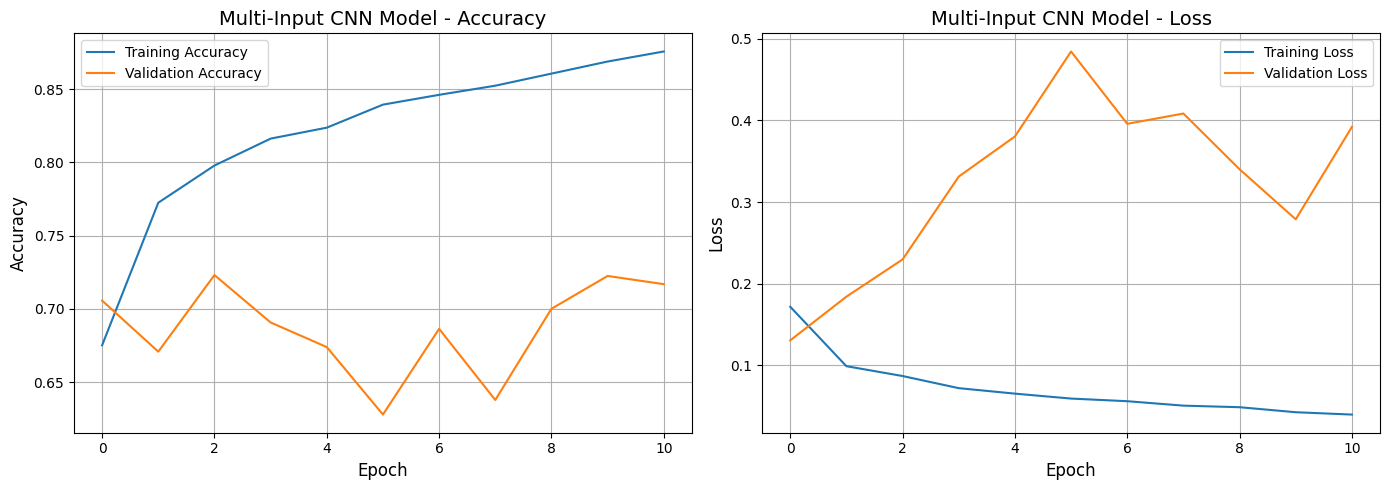

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


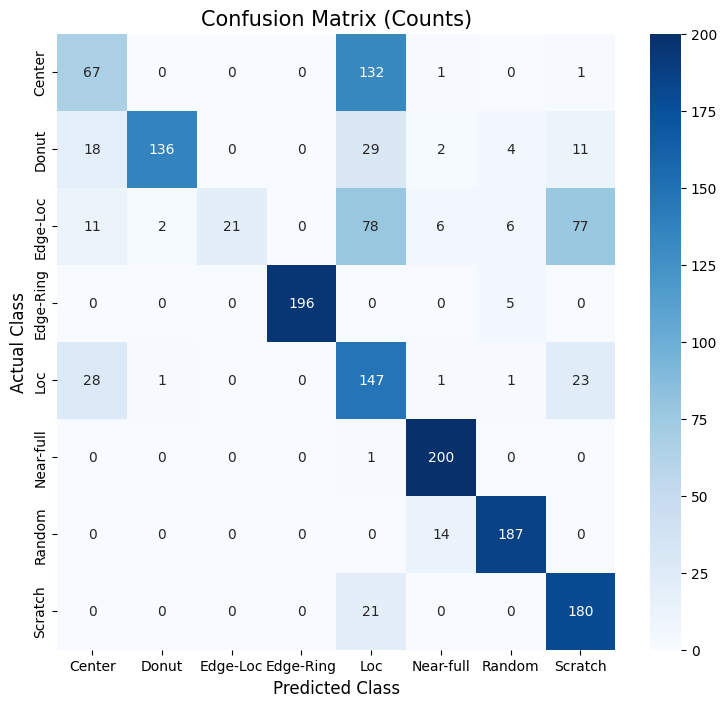

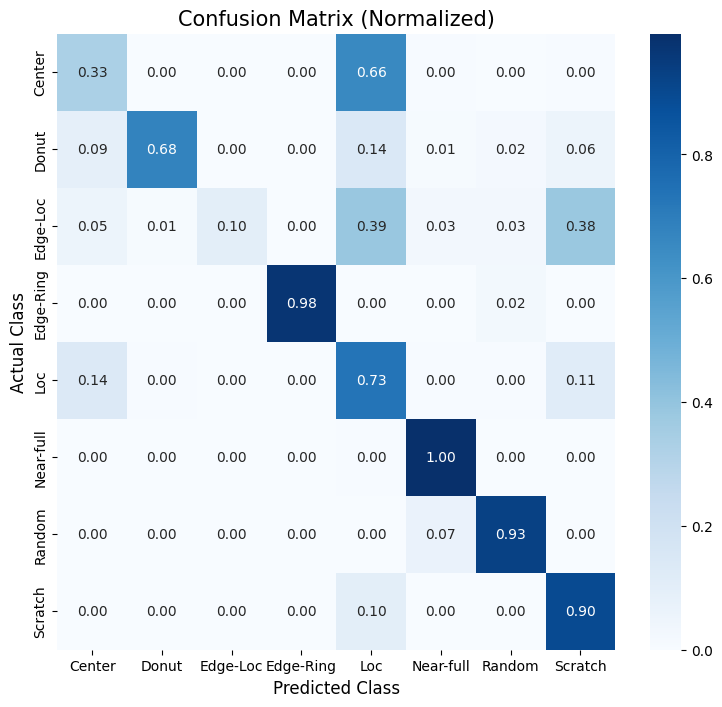

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_cnn, "Multi-Input CNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_cnn.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **5. MobileNetV2 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# MobileNetV2 모델 불러오기
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 MobileNetV2의 가중치 동결
base_model.trainable = False

# 이미지 처리 브랜치
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)

# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 통합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 모델 구성
model_mobilenetv2 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_mobilenetv2.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 불러오기
model_mobilenetv2.summary()


# --- 모델 훈련 ---
history_mobilenetv2 = model_mobilenetv2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/tmp/ipython-input-2331578180.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,442,024 (9.32 MB)

 Trainable params: 183,808 (718.00 KB)

 Non-trainable params: 2,258,216 (8.61 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.2544 - loss: 0.4730 - val_accuracy: 0.6721 - val_loss: 0.1860
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5384 - loss: 0.2133 - val_accuracy: 0.7704 - val_loss: 0.1238
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6342 - loss: 0.1617 - val_accuracy: 0.8326 - val_loss: 0.0845
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6937 - loss: 0.1352 - val_accuracy: 0.8457 - val_loss: 0.0671
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7273 - loss: 0.1144 - val_accuracy: 0.8581 - val_loss: 0.0568
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7513 - loss: 0.1068 - val_accuracy: 0.8662 - val_loss: 0.0523
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7648 - loss: 0.0949 - val_accuracy: 0.8762 - val_loss: 0.0489
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7768 - loss: 0.0861 -

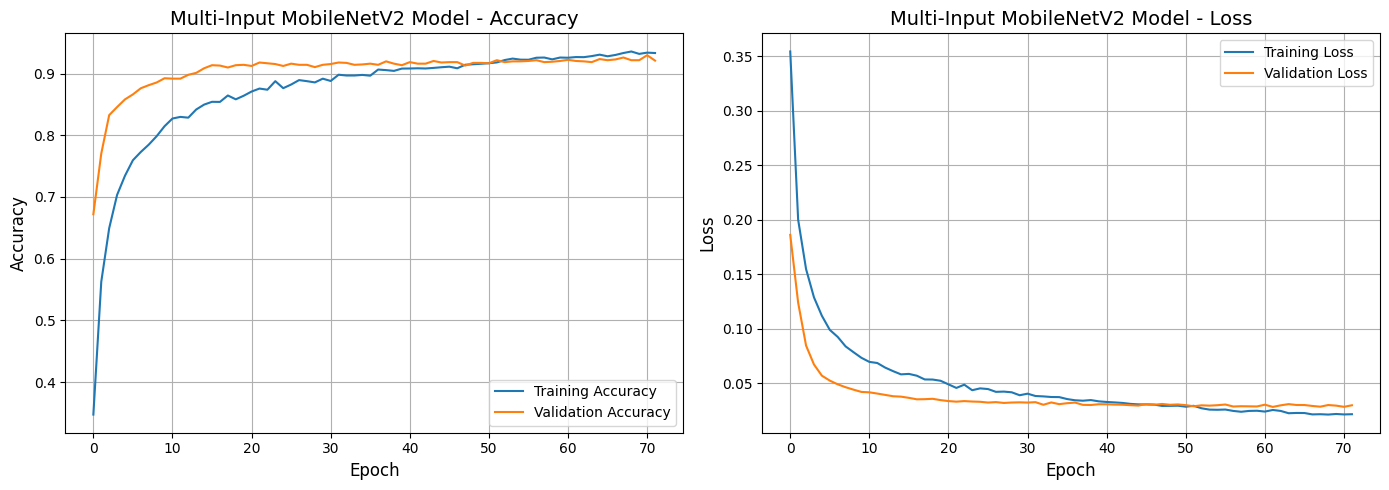

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step


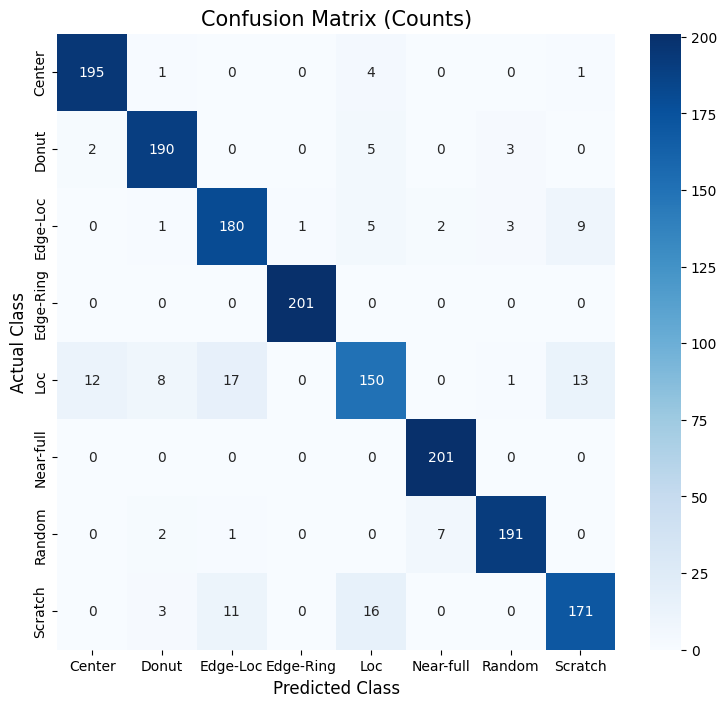

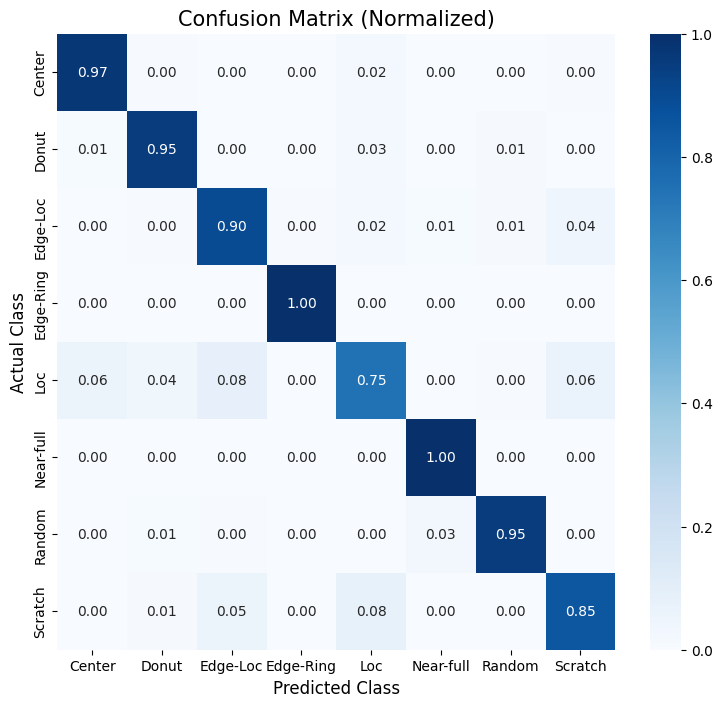

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv2, "Multi-Input MobileNetV2 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_mobilenetv2.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **6. MobileNetV3Small 전이학습**

In [ ]:
# --- 모델 구성 ---
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치
base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_mobilenetv3 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_mobilenetv3.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 전체 모델 구조 출력
model_mobilenetv3.summary()


# --- 모델 훈련 ---
history_mobilenetv3 = model_mobilenetv3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation_5[0][… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,033,048 (3.94 MB)

 Trainable params: 93,696 (366.00 KB)

 Non-trainable params: 939,352 (3.58 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.2222 - loss: 0.4183 - val_accuracy: 0.7075 - val_loss: 0.2050
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5091 - loss: 0.2185 - val_accuracy: 0.7772 - val_loss: 0.1201
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6104 - loss: 0.1598 - val_accuracy: 0.8245 - val_loss: 0.0791
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6736 - loss: 0.1303 - val_accuracy: 0.8531 - val_loss: 0.0607
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7112 - loss: 0.1111 - val_accuracy: 0.8612 - val_loss: 0.0529
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7415 - loss: 0.1037 - val_accuracy: 0.8749 - val_loss: 0.0483
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7723 - loss: 0.0897 - val_accuracy: 0.8799 - val_loss: 0.0458
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7859 - loss: 0.0839 - val_ac

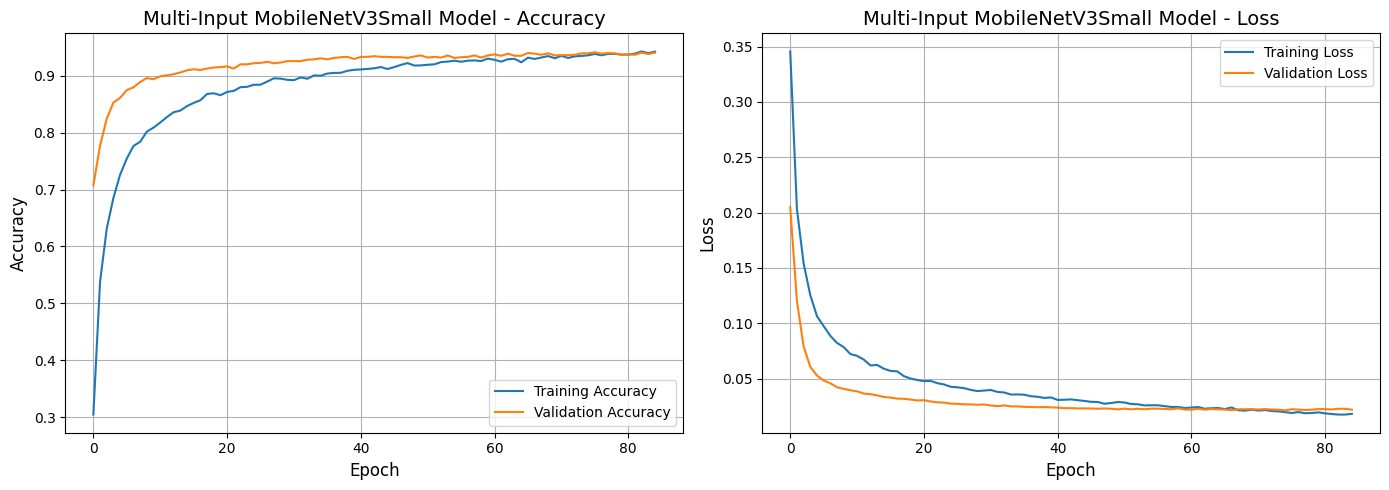

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step


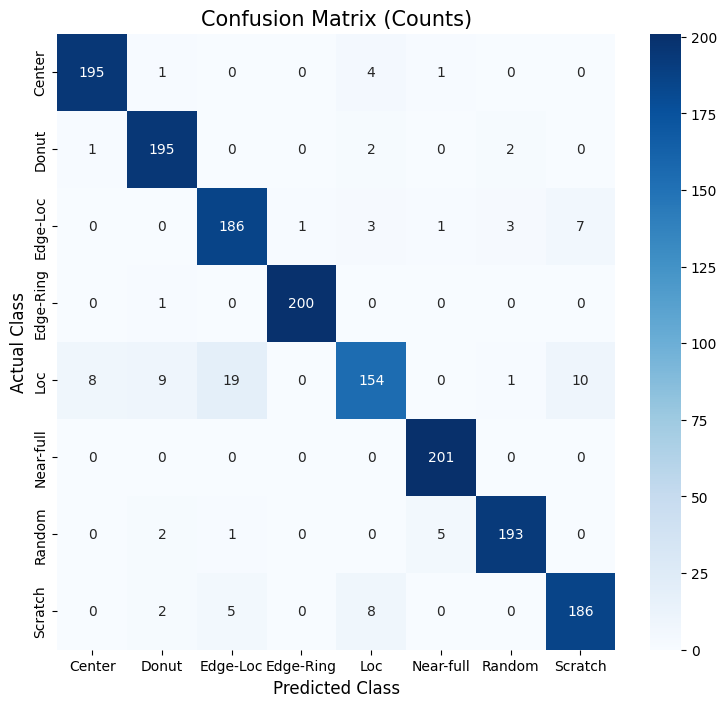

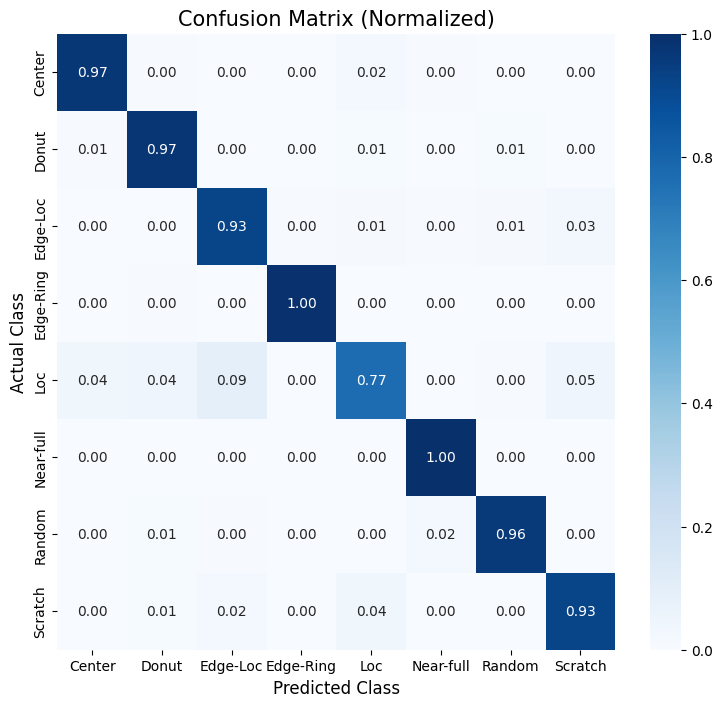

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv3, "Multi-Input MobileNetV3Small Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_mobilenetv3.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **7. ResNet50 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치 (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# ResNet50 모델의 출력에 새로운 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# 연속형 특징 처리 브랜치
branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

#
branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

# 잔차 연결
branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

# 최종 융합
continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 통합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_resnet50 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_resnet50.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_resnet50.summary()


# --- 모델 훈련 ---
history_resnet50 = model_resnet50.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,870,056 (91.06 MB)

 Trainable params: 282,112 (1.08 MB)

 Non-trainable params: 23,587,944 (89.98 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.2727 - loss: 0.5221 - val_accuracy: 0.7237 - val_loss: 0.1596
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5694 - loss: 0.2021 - val_accuracy: 0.7990 - val_loss: 0.1038
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6557 - loss: 0.1506 - val_accuracy: 0.8513 - val_loss: 0.0721
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7298 - loss: 0.1221 - val_accuracy: 0.8612 - val_loss: 0.0590
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7628 - loss: 0.1065 - val_accuracy: 0.8731 - val_loss: 0.0519
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7820 - loss: 0.0929 - val_accuracy: 0.8874 - val_loss: 0.0472
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8003 - loss: 0.0845 - val_accuracy: 0.8955 - val_loss: 0.0438
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8266 - loss: 0.0748 

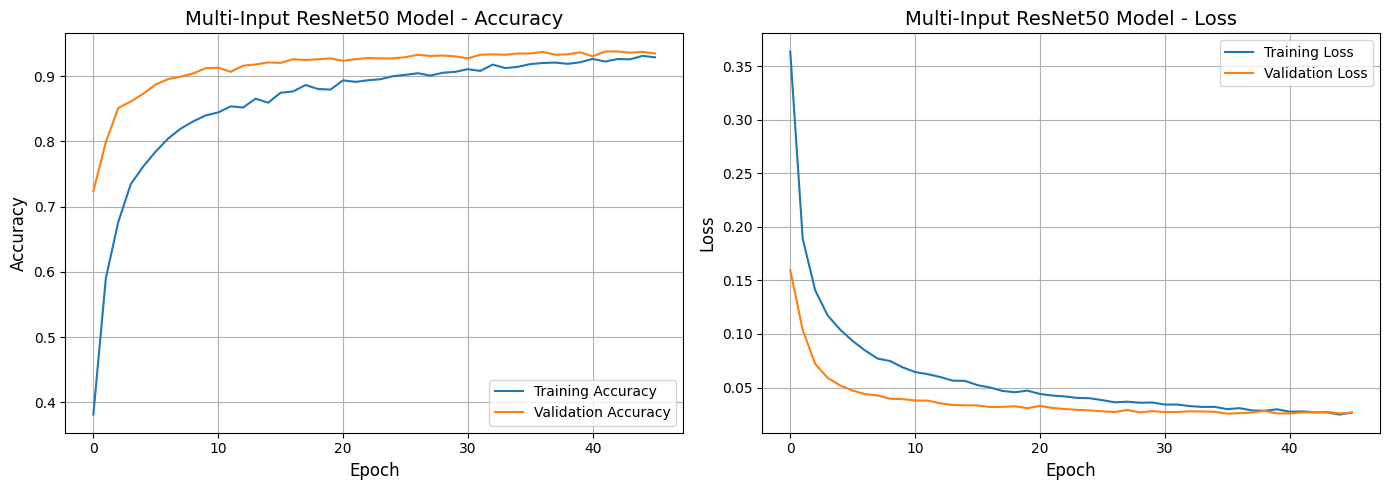

51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step


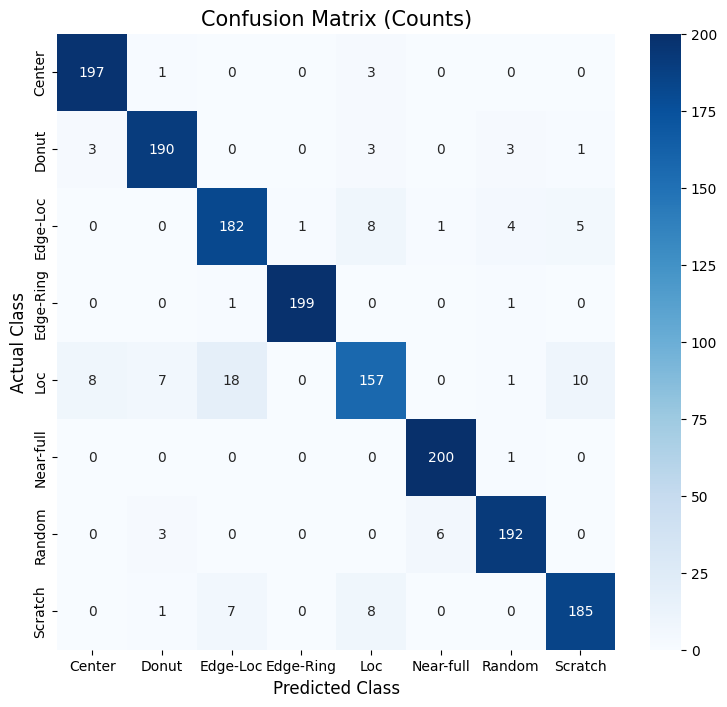

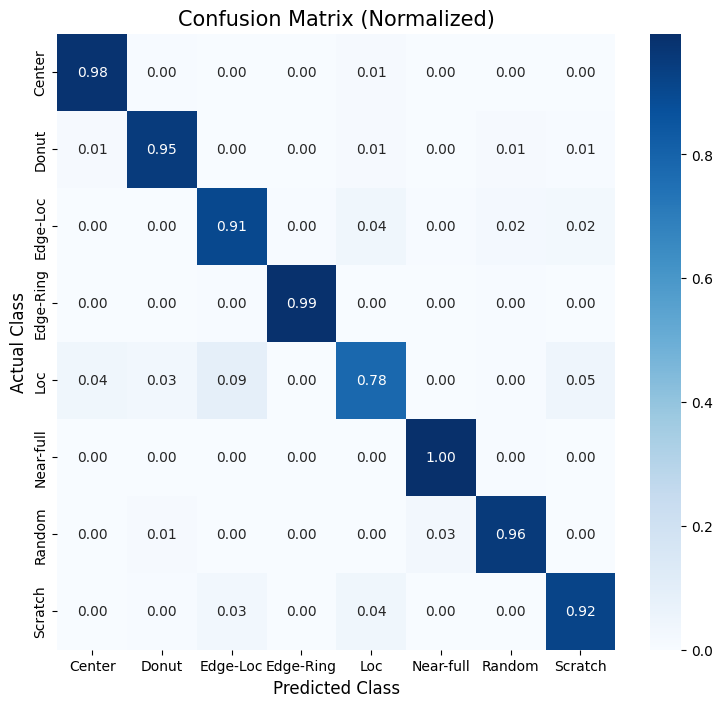

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_resnet50, "Multi-Input ResNet50 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_resnet50.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **8. VGG16 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# VGG16 모델의 출력에 새로운 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 통합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
# num_classes는 이전에 계산된 클래스의 총 개수입니다.
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_vgg16 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_vgg16.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_vgg16.summary()


# --- 모델 훈련 ---
history_vgg16 = model_vgg16.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ image[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ continuous          │ (None, 10)        │          0 │ -               

 Total params: 14,800,424 (56.46 MB)

 Trainable params: 85,504 (334.00 KB)

 Non-trainable params: 14,714,920 (56.13 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - accuracy: 0.1857 - loss: 2.2694 - val_accuracy: 0.5719 - val_loss: 0.2396
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.3444 - loss: 0.8307 - val_accuracy: 0.6478 - val_loss: 0.1630
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.4316 - loss: 0.4211 - val_accuracy: 0.7044 - val_loss: 0.1385
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4976 - loss: 0.2916 - val_accuracy: 0.7455 - val_loss: 0.1184
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.5551 - loss: 0.2271 - val_accuracy: 0.7729 - val_loss: 0.1006
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.5984 - loss: 0.1937 - val_accuracy: 0.7922 - val_loss: 0.0876
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6382 - loss: 0.1590 - val_accuracy: 0.8146 - val_loss: 0.0766
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6685 - loss: 

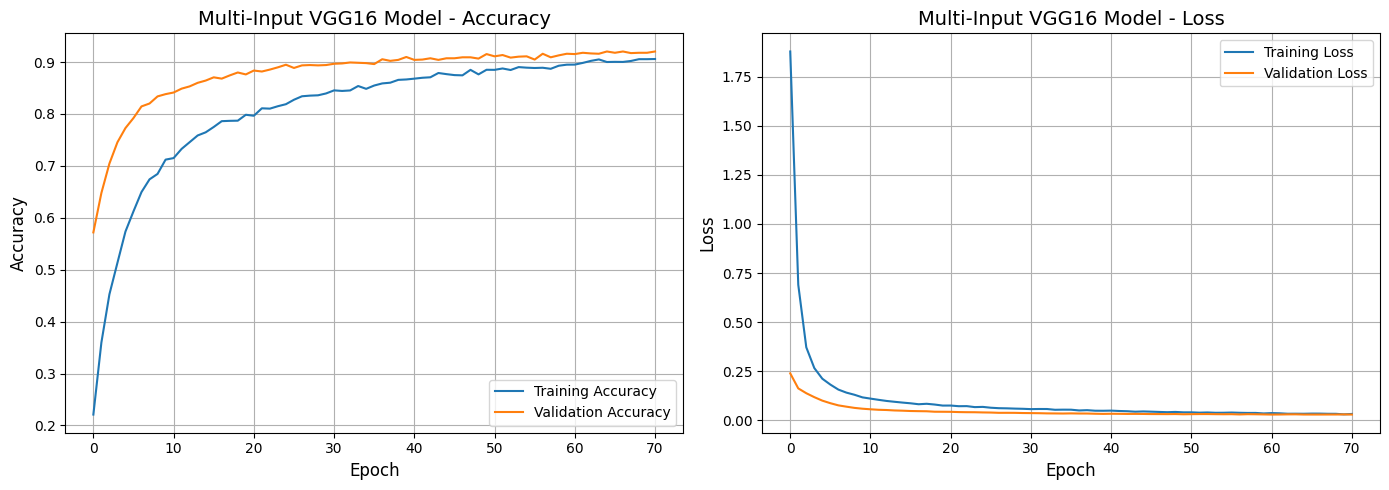

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step


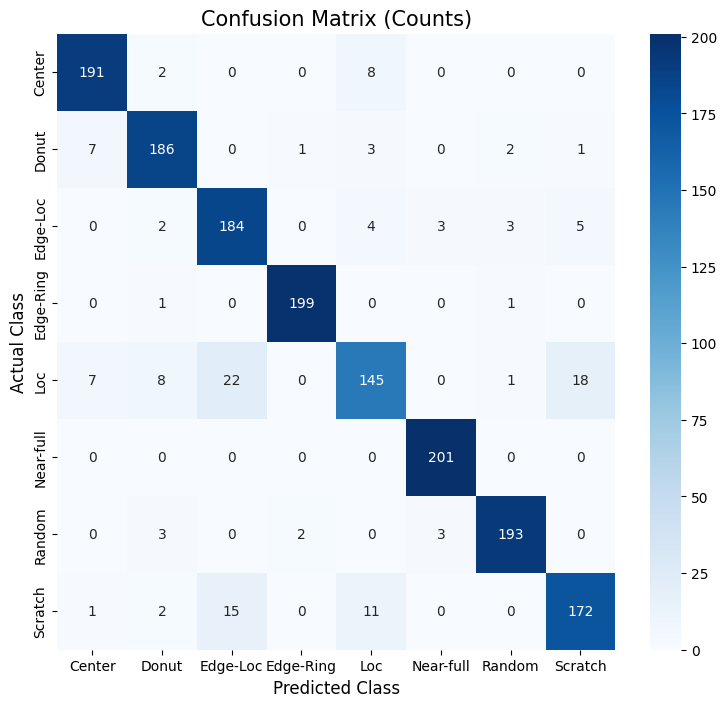

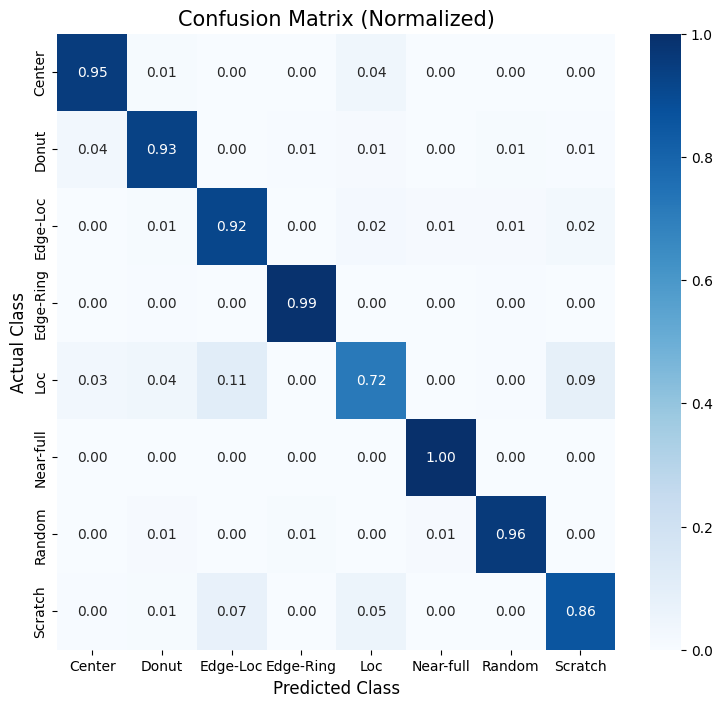

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_vgg16, "Multi-Input VGG16 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_vgg16.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **9. InceptionV3 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (InceptionV3)
base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_inceptionv3 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_inceptionv3.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_inceptionv3.summary()


# --- 모델 훈련 ---
history_inceptionv3 = model_inceptionv3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 63, 63,    │        864 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │      9,216 │ activation_26[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │     18,432 │ activation_27[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ activation_28[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 30, 30,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    138,240 │ activation_29[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 22,085,128 (84.25 MB)

 Trainable params: 282,112 (1.08 MB)

 Non-trainable params: 21,803,016 (83.17 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 49s 142ms/step - accuracy: 0.1353 - loss: 3.4047 - val_accuracy: 0.1456 - val_loss: 3.3438
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.1661 - loss: 3.2806 - val_accuracy: 0.2607 - val_loss: 2.8548
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2253 - loss: 3.0026 - val_accuracy: 0.4138 - val_loss: 2.3000
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2844 - loss: 2.7391 - val_accuracy: 0.4368 - val_loss: 2.1593
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3550 - loss: 2.4254 - val_accuracy: 0.5619 - val_loss: 1.5852
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4060 - loss: 2.1569 - val_accuracy: 0.5744 - val_loss: 1.3816
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4549 - loss: 1.2377 - val_accuracy: 0.6198 - val_loss: 0.1786
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4938 - loss: 0.2399 

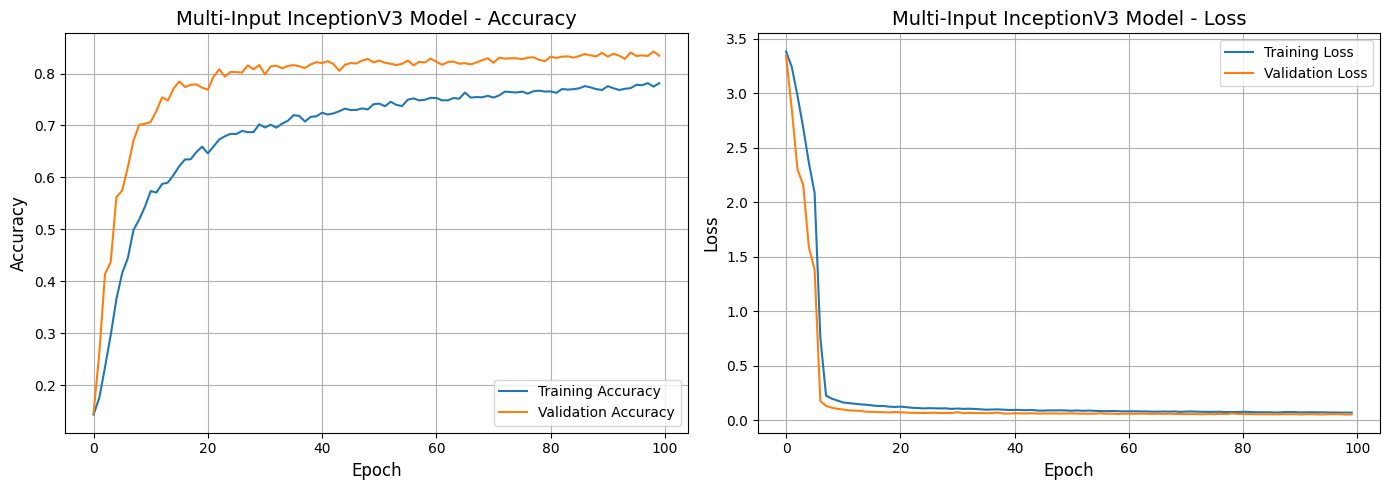

51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step


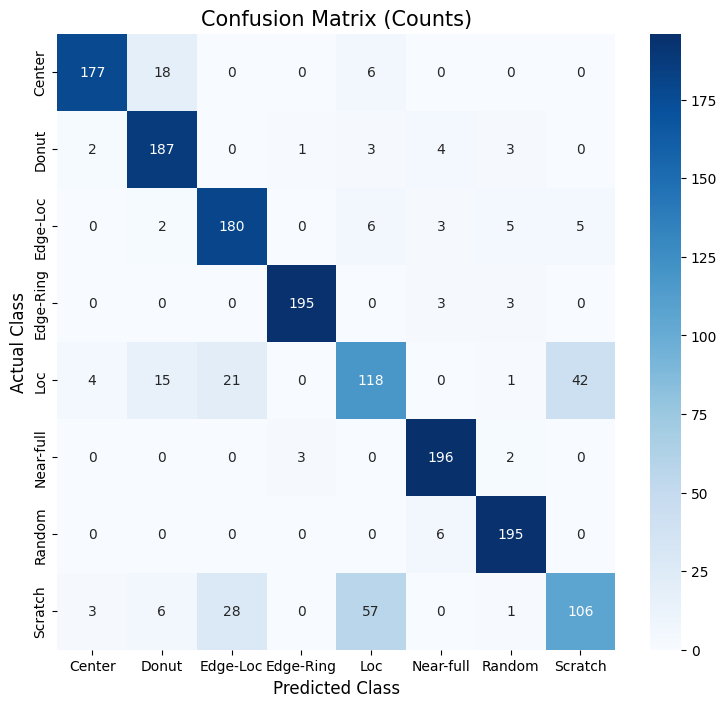

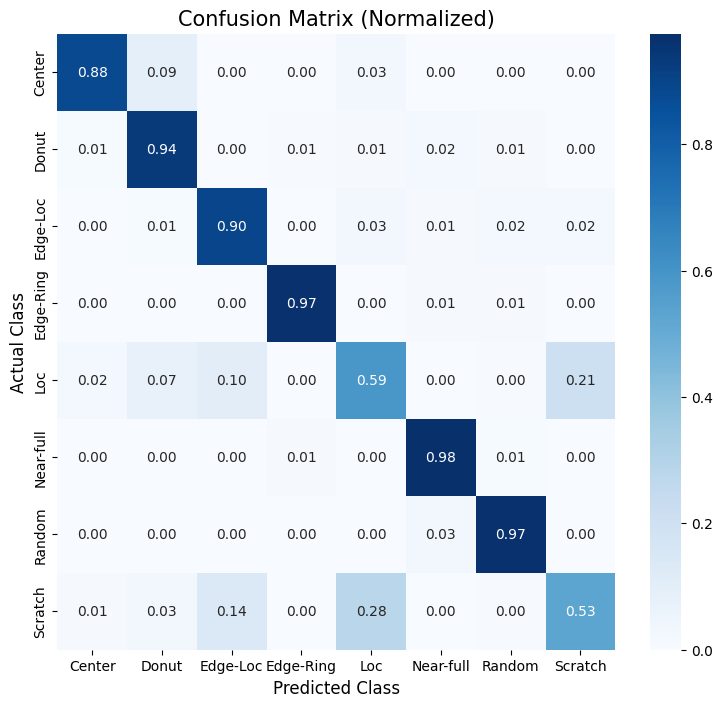

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_inceptionv3, "Multi-Input InceptionV3 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_inceptionv3.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **10. Xception 전이학습**

In [ ]:

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (Xception)
base_model = Xception(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_xception = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_xception.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_xception.summary()


# --- 모델 훈련 ---
history_xception = model_xception.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ image[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_18[0][0]    

 Total params: 21,143,824 (80.66 MB)

 Trainable params: 282,112 (1.08 MB)

 Non-trainable params: 20,861,712 (79.58 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - accuracy: 0.1613 - loss: 2.7618 - val_accuracy: 0.4412 - val_loss: 0.4387
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.2900 - loss: 0.8464 - val_accuracy: 0.5943 - val_loss: 0.2442
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.4366 - loss: 0.2778 - val_accuracy: 0.7007 - val_loss: 0.1707
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5073 - loss: 0.2264 - val_accuracy: 0.7436 - val_loss: 0.1254
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5648 - loss: 0.1926 - val_accuracy: 0.7679 - val_loss: 0.1066
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5999 - loss: 0.1708 - val_accuracy: 0.8164 - val_loss: 0.0857
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.6212 - loss: 0.1539 - val_accuracy: 0.8395 - val_loss: 0.0780
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.6594 - loss: 

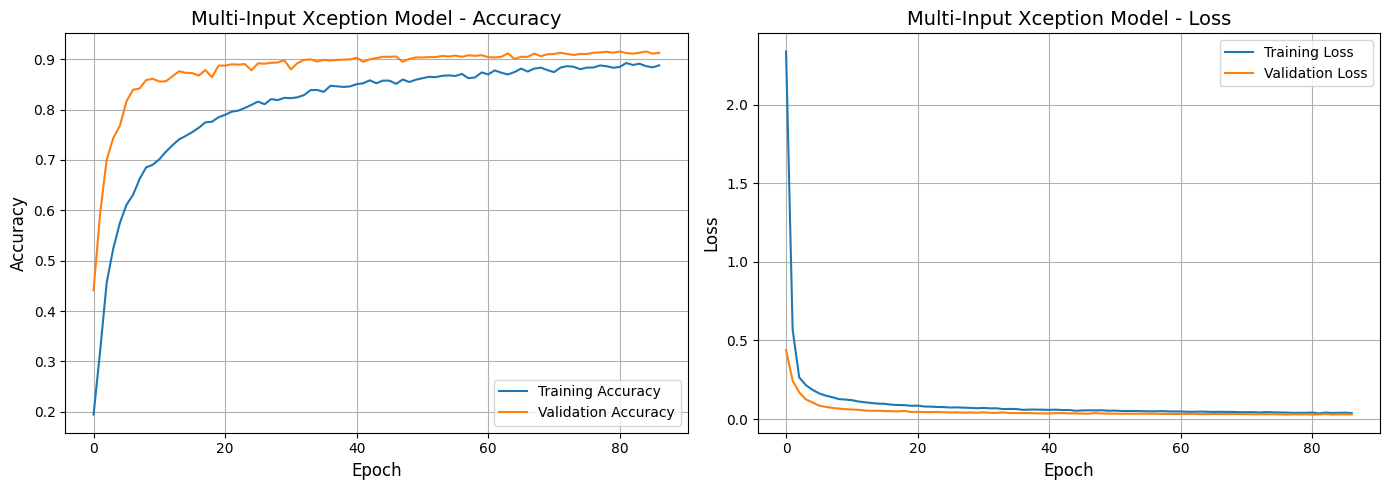

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step


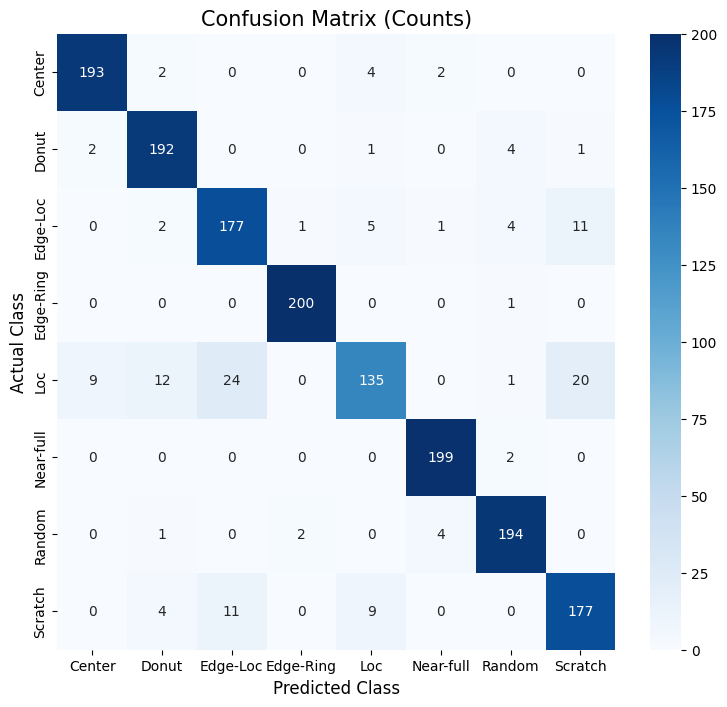

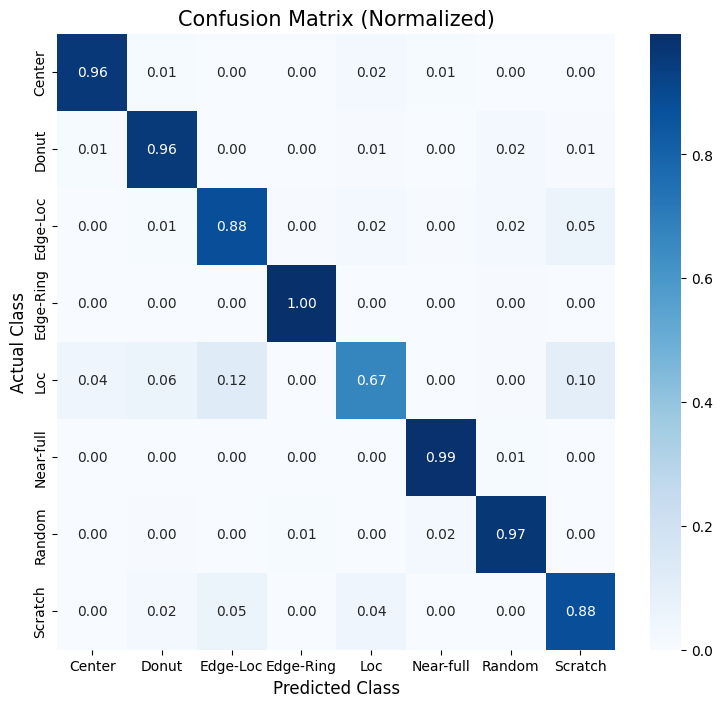

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_xception, "Multi-Input Xception Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_xception.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **11. DenseNet121 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (DenseNet121)
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃

# 연속형 특징 처리 브랜치

branch0 = Lambda(lambda feat: tf.concat([
        feat[:, :7],  # 기본 좌표 특징들
        tf.math.log1p(tf.maximum(feat[:, 7:8], 1e-6)),  # area_norm 로그변환
        feat[:, 8:9],  # aspect_log (이미 로그)
        feat[:, 9:]   # edge_margin
    ], axis=-1))(continuous_input)

branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

r_area = Multiply()([
      Lambda(lambda branch0: branch0[:, 4:5])(branch0),  # r_norm
      Lambda(lambda branch0: branch0[:, 7:8])(branch0)   # area_norm (변환된)
    ])
angle_interaction = Multiply()([
      Lambda(lambda branch0: branch0[:, 5:6])(branch0),  # sin_theta
      Lambda(lambda branch0: branch0[:, 6:7])(branch0)   # cos_theta
    ])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

continuous_features = concatenate([branch1, branch2, branch3])


# 범주형 특징 처리 브랜치
rad_bin_features = Embedding(input_dim=8, output_dim=4)(rad_bin_input)
rad_bin_features = Flatten()(rad_bin_features)  # 임베딩 결과를 1차원 벡터로 만듭니다.

sec_bin_features = Embedding(input_dim=16, output_dim=8)(sec_bin_input)
sec_bin_features = Flatten()(sec_bin_features)


# 최적 임베딩 차원 계산 (경험적 공식)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=tf.keras.regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩
rad_pos = Lambda(lambda x: tf.cast(x, tf.float32) / 8.0)(rad_bin_input)  # 정규화
sec_angle = Lambda(lambda x: tf.cast(x, tf.float32) * 2 * 3.14159 / 16.0)(sec_bin_input)
sec_sin = Lambda(lambda x: tf.sin(x))(sec_angle)
sec_cos = Lambda(lambda x: tf.cos(x))(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])


# 브랜치 결합
combined = concatenate([
    image_features,
    continuous_features,
    categorical_features
])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_densenet121 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_densenet121.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_densenet121.summary()


# --- 모델 훈련 ---
history_densenet121 = model_densenet121.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,188,776 (27.42 MB)

 Trainable params: 151,040 (590.00 KB)

 Non-trainable params: 7,037,736 (26.85 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 76s 222ms/step - accuracy: 0.1606 - loss: 3.0874 - val_accuracy: 0.4468 - val_loss: 1.2381
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.3063 - loss: 2.0288 - val_accuracy: 0.6646 - val_loss: 0.2095
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4300 - loss: 0.4724 - val_accuracy: 0.7013 - val_loss: 0.1613
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4994 - loss: 0.2572 - val_accuracy: 0.7859 - val_loss: 0.1243
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5769 - loss: 0.2081 - val_accuracy: 0.8183 - val_loss: 0.0981
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6256 - loss: 0.1746 - val_accuracy: 0.8388 - val_loss: 0.0830
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6433 - loss: 0.1564 - val_accuracy: 0.8351 - val_loss: 0.0755
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6735 - loss: 0.1446 

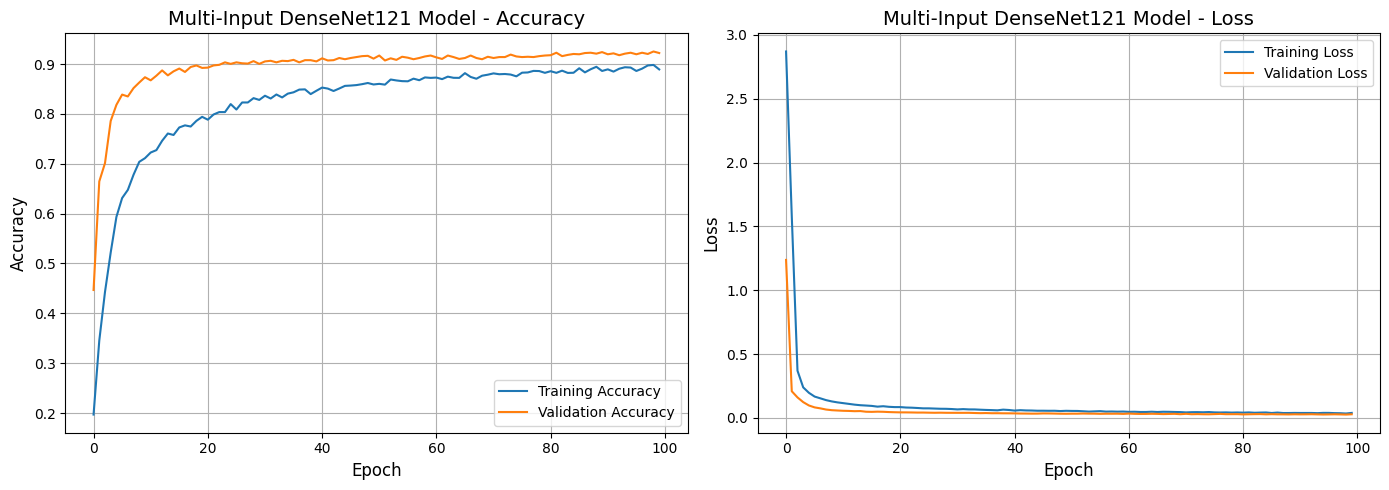

51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 239ms/step


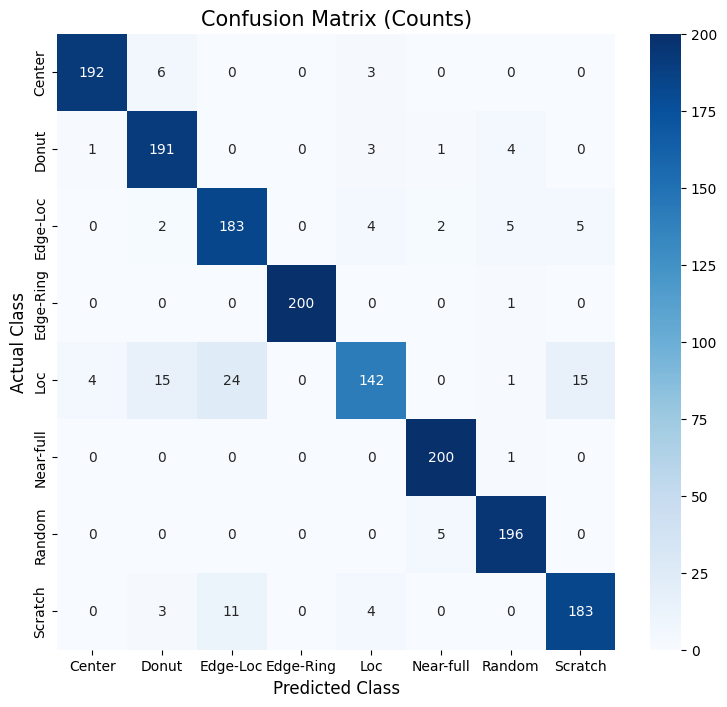

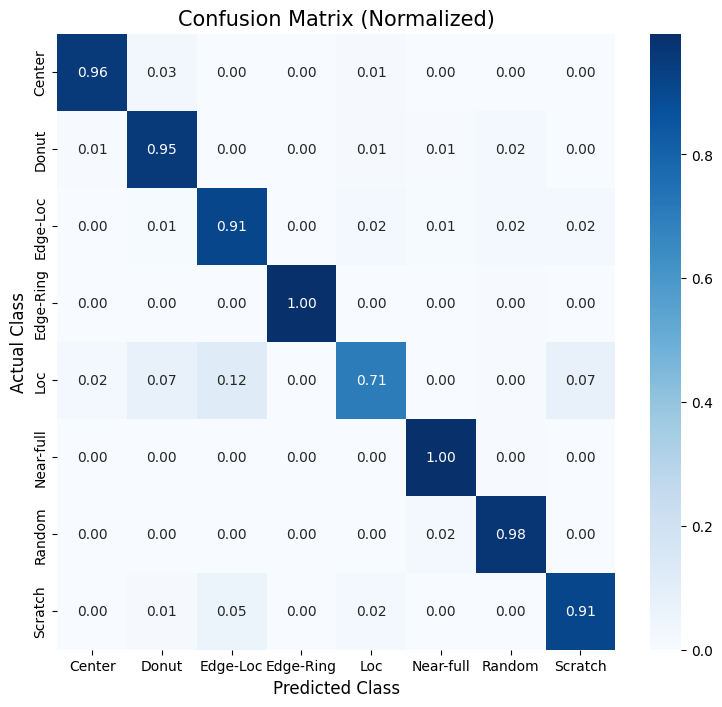

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_densenet121, "Multi-Input DenseNet121 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_densenet121.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

# **성능 비교 결과**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 이전에 훈련시킨 모델 변수들을 사용합니다.
models_to_evaluate = {
    "Simple NN": model_simple_nn,
    "DNN": model_dnn,
    "ANN": model_ann,
    "Custom CNN": model_cnn,
    "MobileNetV2": model_mobilenetv2,
    "MobileNetV3Small": model_mobilenetv3,
    "ResNet50": model_resnet50,
    "VGG16": model_vgg16,
    "InceptionV3": model_inceptionv3,
    "Xception": model_xception,
    "DenseNet121": model_densenet121
}

# 평가 결과를 저장할 리스트
results = []

# 원-핫 인코딩된 y_test를 다시 정수 라벨로 변환
y_test_integer_labels = np.argmax(y_test, axis=1)

# 성능 평가
for model_name, model in models_to_evaluate.items():
    print(f"Evaluating {model_name}...")

    # 예측을 수행할 때 4개의 입력을 담은 'X_test' 딕셔너리를 전달합니다.
    y_pred_probs = model.predict(X_test, verbose=0)

    # 예측된 확률에서 가장 높은 값의 인덱스를 찾아 최종 클래스로 변환
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # 3. 평가 지표 계산
    accuracy = accuracy_score(y_test_integer_labels, y_pred_classes)
    precision = precision_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)
    recall = recall_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)

    # 4. 결과 저장
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# --- 5. 최종 결과를 DataFrame으로 변환하고 정렬 ---
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n\n--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---")
display(results_df_sorted)

Evaluating Simple NN...
Evaluating DNN...
Evaluating ANN...
Evaluating Custom CNN...
Evaluating MobileNetV2...
Evaluating MobileNetV3Small...
Evaluating ResNet50...
Evaluating VGG16...
Evaluating InceptionV3...
Evaluating Xception...
Evaluating DenseNet121...


--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,MobileNetV3Small,0.939639,0.939261,0.939639,0.938586
1,ResNet50,0.934661,0.933981,0.934661,0.933874
2,DenseNet121,0.925327,0.926258,0.925327,0.923729
3,MobileNetV2,0.920348,0.919083,0.920348,0.919210
4,VGG16,0.915370,0.914776,0.915370,0.914115
5,Xception,0.912881,0.912369,0.912881,0.910650
6,InceptionV3,0.842564,0.838096,0.842564,0.837637
7,Custom CNN,0.705663,0.788571,0.705663,0.683822
8,ANN,0.191039,0.135225,0.191039,0.144205
9,DNN,0.125078,0.015644,0.125078,0.027810
